In [7]:
# --- Cell 1: Imports ---
import os
import shutil
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Concatenate, Input, Dropout
from tensorflow.keras.models import Model

print("✅ Cell 1: นำเข้าเครื่องมือพร้อมสร้างสมอง Fusion แล้ว!")

✅ Cell 1: นำเข้าเครื่องมือพร้อมสร้างสมอง Fusion แล้ว!


In [8]:
# --- Cell 2: Prepare Datasets ---
base_dir = '/kaggle/working/datasets'
if os.path.exists(base_dir): shutil.rmtree(base_dir)

dir_waste = os.path.join(base_dir, 'waste')
dir_animal = os.path.join(base_dir, 'animal')
dir_combined = os.path.join(base_dir, 'combined')

for d in [dir_waste, dir_animal, dir_combined]:
    os.makedirs(d, exist_ok=True)

# ค้นหา Source ข้อมูล
garbage_src, animal_src = None, None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'battery' in dirs and 'plastic' in dirs: garbage_src = root
    if 'animals' in root.lower() and any(os.path.isdir(os.path.join(root, d)) for d in dirs): animal_src = root

waste_classes = ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

print("⏳ กำลังจัดเตรียมข้อมูล (ใช้ Symlink เพื่อความรวดเร็ว)...")
# 1. จัดเตรียม Waste Dataset และ Combined Dataset (ส่วนขยะ)
for cls in waste_classes:
    os.makedirs(os.path.join(dir_waste, cls), exist_ok=True)
    os.makedirs(os.path.join(dir_combined, cls), exist_ok=True)
    src_cls = os.path.join(garbage_src, cls)
    if os.path.exists(src_cls):
        for img in os.listdir(src_cls):
            if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                os.symlink(os.path.join(src_cls, img), os.path.join(dir_waste, cls, img))
                os.symlink(os.path.join(src_cls, img), os.path.join(dir_combined, cls, img))

# 2. จัดเตรียม Animal Dataset และ Combined Dataset (ส่วนสัตว์)
os.makedirs(os.path.join(dir_animal, 'animal'), exist_ok=True)
os.makedirs(os.path.join(dir_animal, 'not_animal'), exist_ok=True)
os.makedirs(os.path.join(dir_combined, 'animal'), exist_ok=True)

all_animals, all_wastes = [], []
if animal_src:
    for r, d, f in os.walk(animal_src):
        for img in f:
            if img.lower().endswith(('.png', '.jpg', '.jpeg')): all_animals.append(os.path.join(r, img))
for r, d, f in os.walk(dir_waste):
    for img in f: all_wastes.append(os.path.join(r, img))

# สุ่มสัตว์ 1,500 รูป และขยะ 1,500 รูป เพื่อใช้แยก Animal vs Not Animal
for i, img_path in enumerate(random.sample(all_animals, min(1500, len(all_animals)))):
    os.symlink(img_path, os.path.join(dir_animal, 'animal', f'anim_{i}.jpg'))
    os.symlink(img_path, os.path.join(dir_combined, 'animal', f'anim_{i}.jpg'))
for i, img_path in enumerate(random.sample(all_wastes, min(1500, len(all_wastes)))):
    os.symlink(img_path, os.path.join(dir_animal, 'not_animal', f'waste_{i}.jpg'))

print("✅ Cell 2: เตรียมข้อมูลเสร็จสิ้นทั้ง 3 ชุดแล้ว!")

⏳ กำลังจัดเตรียมข้อมูล (ใช้ Symlink เพื่อความรวดเร็ว)...
✅ Cell 2: เตรียมข้อมูลเสร็จสิ้นทั้ง 3 ชุดแล้ว!


In [9]:
# --- Cell 3: Train Waste Expert (10 Epochs) ---
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
gen_waste_t = datagen.flow_from_directory(dir_waste, target_size=(224, 224), batch_size=32, subset='training', class_mode='categorical')
gen_waste_v = datagen.flow_from_directory(dir_waste, target_size=(224, 224), batch_size=32, subset='validation', class_mode='categorical')

# 🛠️ แก้ไข: เติม name="base_waste" ไม่ให้ชื่อซ้ำ
base_waste = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), name="base_waste")
base_waste.trainable = False 
x_waste = GlobalAveragePooling2D(name="pool_waste")(base_waste.output)
out_waste = Dense(12, activation='softmax', name="dense_waste")(x_waste)
model_waste = Model(inputs=base_waste.input, outputs=out_waste, name="model_waste")

model_waste.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\n🚀 เริ่มเทรนสมองขยะ (Waste Expert) 10 Epochs...")
model_waste.fit(gen_waste_t, validation_data=gen_waste_v, epochs=10)
print("✅ Cell 3: เทรนสมองขยะเสร็จสิ้น!")

Found 12415 images belonging to 12 classes.
Found 3100 images belonging to 12 classes.

🚀 เริ่มเทรนสมองขยะ (Waste Expert) 10 Epochs...
Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 53s 116ms/step - accuracy: 0.7612 - loss: 0.8003 - val_accuracy: 0.8868 - val_loss: 0.3388
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9398 - loss: 0.2064 - val_accuracy: 0.9029 - val_loss: 0.2866
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.9581 - loss: 0.1481 - val_accuracy: 0.9139 - val_loss: 0.2582
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.9697 - loss: 0.1098 - val_accuracy: 0.9123 - val_loss: 0.2588
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.9778 - loss: 0.0863 - val_accuracy: 0.9081 - val_loss: 0.2723
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 31s 81ms/step - accuracy: 0.9799 - loss: 0.0770 - val_accuracy: 0.9100 - val_loss: 0.2585
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.9846 - loss: 0.0

In [10]:
# --- Cell 4: Train Animal Expert (10 Epochs) ---
gen_anim_t = datagen.flow_from_directory(dir_animal, target_size=(224, 224), batch_size=32, subset='training', class_mode='categorical')
gen_anim_v = datagen.flow_from_directory(dir_animal, target_size=(224, 224), batch_size=32, subset='validation', class_mode='categorical')

# 🛠️ แก้ไข: เติม name="base_animal" ไม่ให้ชื่อซ้ำ
base_animal = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), name="base_animal")
base_animal.trainable = False 
x_animal = GlobalAveragePooling2D(name="pool_animal")(base_animal.output)
out_anim = Dense(2, activation='softmax', name="dense_animal")(x_animal)
model_animal = Model(inputs=base_animal.input, outputs=out_anim, name="model_animal")

model_animal.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\n🚀 เริ่มเทรนสมองสัตว์ (Animal Expert) 10 Epochs...")
model_animal.fit(gen_anim_t, validation_data=gen_anim_v, epochs=10)
print("✅ Cell 4: เทรนสมองสัตว์เสร็จสิ้น!")

Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.

🚀 เริ่มเทรนสมองสัตว์ (Animal Expert) 10 Epochs...
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 356ms/step - accuracy: 0.8266 - loss: 0.3691 - val_accuracy: 0.9633 - val_loss: 0.1397
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 156ms/step - accuracy: 0.9720 - loss: 0.0949 - val_accuracy: 0.9683 - val_loss: 0.1135
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 155ms/step - accuracy: 0.9861 - loss: 0.0589 - val_accuracy: 0.9683 - val_loss: 0.1048
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 159ms/step - accuracy: 0.9822 - loss: 0.0601 - val_accuracy: 0.9750 - val_loss: 0.0762
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.9903 - loss: 0.0347 - val_accuracy: 0.9767 - val_loss: 0.0742
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.9962 - loss: 0.0283 - val_accuracy: 0.9783 - val_loss: 0.0727
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - accuracy: 0.9980 - loss: 0.0225 - val

In [11]:
# --- Cell 5: Fusion Mode - Train Combined Model (10 Epochs) ---
gen_comb_t = datagen.flow_from_directory(dir_combined, target_size=(224, 224), batch_size=32, subset='training', class_mode='categorical')
gen_comb_v = datagen.flow_from_directory(dir_combined, target_size=(224, 224), batch_size=32, subset='validation', class_mode='categorical')

inputs = Input(shape=(224, 224, 3), name="fusion_input")

# ให้ภาพวิ่งผ่านสมองขยะ
feat_waste = base_waste(inputs)
feat_waste = GlobalAveragePooling2D(name="fusion_pool_waste")(feat_waste)

# ให้ภาพวิ่งผ่านสมองสัตว์
feat_animal = base_animal(inputs)
feat_animal = GlobalAveragePooling2D(name="fusion_pool_animal")(feat_animal)

# เอาความรู้มาเชื่อมต่อกัน
merged = Concatenate(name="fusion_concat")([feat_waste, feat_animal])

# ชั้นวิเคราะห์ขั้นสุดท้าย สำหรับ 13 คลาส
x = Dense(256, activation='relu', name="fusion_dense_1")(merged)
x = Dropout(0.3, name="fusion_dropout")(x)
outputs = Dense(13, activation='softmax', name="fusion_output")(x)

# สร้างโมเดลสมบูรณ์แบบ
fusion_model = Model(inputs=inputs, outputs=outputs, name="Final_Fusion_Model")
fusion_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🌟 เริ่มเทรนร่างสมบูรณ์ (Fusion Model) 13 คลาส 10 Epochs...")
fusion_model.fit(gen_comb_t, validation_data=gen_comb_v, epochs=10)

model_path = '/kaggle/working/fusion_smart_waste.keras'
fusion_model.save(model_path)
print(f"\n🎉 สำเร็จ! ดาวน์โหลดไฟล์นี้ไปใช้ใน Hugging Face ได้เลย: {model_path}")

Found 13615 images belonging to 13 classes.
Found 3400 images belonging to 13 classes.

🌟 เริ่มเทรนร่างสมบูรณ์ (Fusion Model) 13 คลาส 10 Epochs...
Epoch 1/10
255/426 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.7836 - loss: 0.7355

2026-05-16 06:55:21.176234: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 06:55:21.317946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8169 - loss: 0.6167

2026-05-16 06:56:03.130348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 06:56:03.286648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 06:56:03.422528: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


426/426 ━━━━━━━━━━━━━━━━━━━━ 91s 179ms/step - accuracy: 0.8170 - loss: 0.6163 - val_accuracy: 0.9035 - val_loss: 0.2930
Epoch 2/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9354 - loss: 0.2022 - val_accuracy: 0.8879 - val_loss: 0.3525
Epoch 3/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9535 - loss: 0.1382 - val_accuracy: 0.9074 - val_loss: 0.2939
Epoch 4/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9609 - loss: 0.1153 - val_accuracy: 0.9065 - val_loss: 0.3222
Epoch 5/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9715 - loss: 0.0864 - val_accuracy: 0.9300 - val_loss: 0.2561
Epoch 6/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9732 - loss: 0.0766 - val_accuracy: 0.9159 - val_loss: 0.3058
Epoch 7/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9780 - loss: 0.0636 - val_accuracy: 0.9244 - val_loss: 0.2624
Epoch 8/10
426/426 ━━━━━━━━━━━━━━━━━━━━ 45s 105ms/step - accuracy: 0.9779 - loss: 0.0615 - val_ac

📊 กำลังเตรียมข้อมูลเพื่อสร้างกราฟ...
Found 3400 images belonging to 13 classes.
🔍 AI กำลังไล่ทายภาพทีละภาพเพื่อทำรายงาน...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step


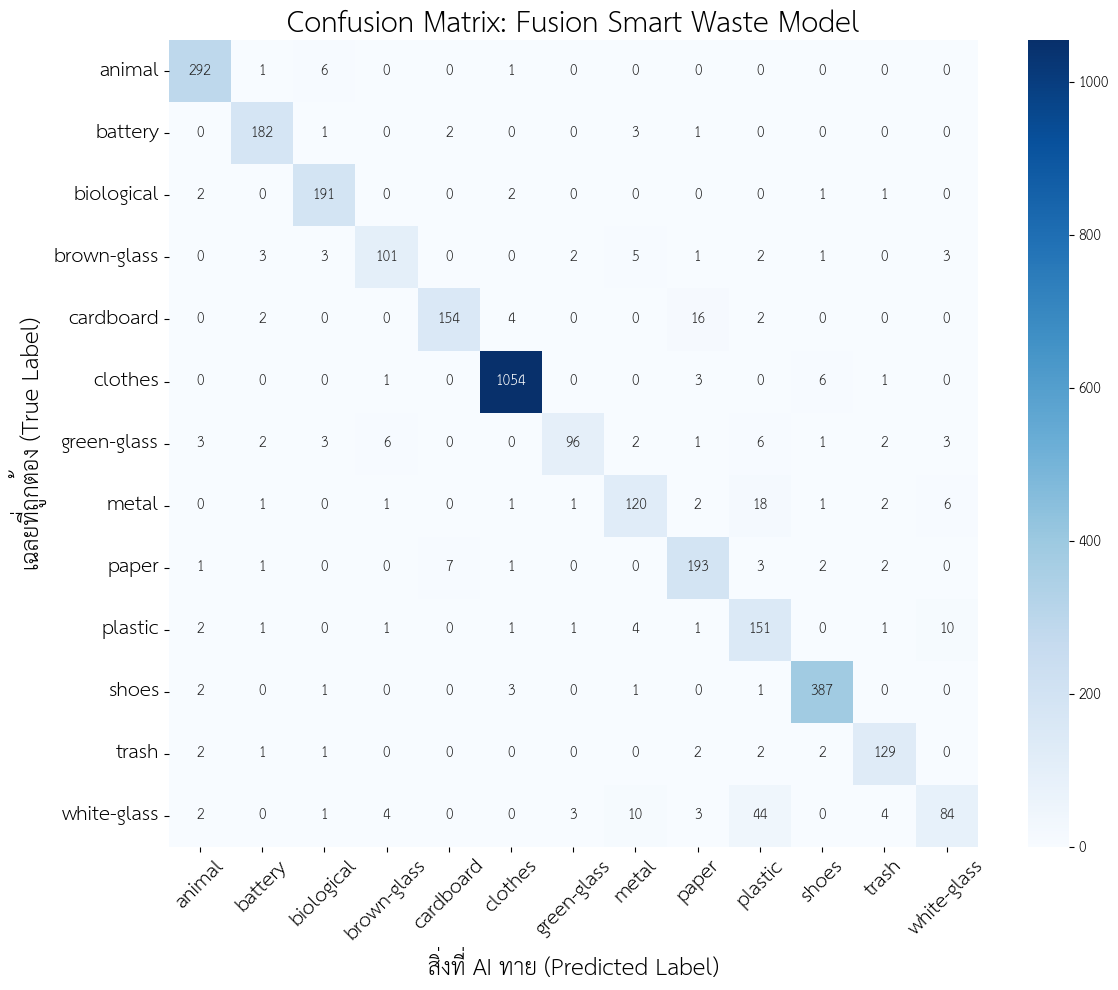


📝 สรุปรายงานผลการแยกขยะแต่ละชนิด:
              precision    recall  f1-score   support

      animal       0.95      0.97      0.96       300
     battery       0.94      0.96      0.95       189
  biological       0.92      0.97      0.95       197
 brown-glass       0.89      0.83      0.86       121
   cardboard       0.94      0.87      0.90       178
     clothes       0.99      0.99      0.99      1065
 green-glass       0.93      0.77      0.84       125
       metal       0.83      0.78      0.81       153
       paper       0.87      0.92      0.89       210
     plastic       0.66      0.87      0.75       173
       shoes       0.97      0.98      0.97       395
       trash       0.91      0.93      0.92       139
 white-glass       0.79      0.54      0.64       155

    accuracy                           0.92      3400
   macro avg       0.89      0.88      0.88      3400
weighted avg       0.92      0.92      0.92      3400



In [14]:
# --- Cell 6: ประเมินผลลัพธ์ (แก้ปัญหาสี่เหลี่ยมภาษาไทยแล้ว) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# 1. โหลดและตั้งค่าฟอนต์ภาษาไทย
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False # ป้องกันบั๊กเครื่องหมายลบ

print("📊 กำลังเตรียมข้อมูลเพื่อสร้างกราฟ...")

# 2. สร้าง Generator เฉพาะสำหรับตอนสอบ 
gen_comb_eval = datagen.flow_from_directory(
    dir_combined, 
    target_size=(224, 224), 
    batch_size=32, 
    subset='validation', 
    class_mode='categorical',
    shuffle=False
)

print("🔍 AI กำลังไล่ทายภาพทีละภาพเพื่อทำรายงาน...")
predictions = fusion_model.predict(gen_comb_eval, steps=len(gen_comb_eval))
y_pred = np.argmax(predictions, axis=1)
y_true = gen_comb_eval.classes 

class_names = list(gen_comb_eval.class_indices.keys())

# 3. สร้างกราฟ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Fusion Smart Waste Model', fontsize=20)
plt.ylabel('เฉลยที่ถูกต้อง (True Label)', fontsize=16)
plt.xlabel('สิ่งที่ AI ทาย (Predicted Label)', fontsize=16)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

# 4. แสดงรายงานผลสอบ
print("\n📝 สรุปรายงานผลการแยกขยะแต่ละชนิด:")
print(classification_report(y_true, y_pred, target_names=class_names))